# Bài Kiểm Tra Thực Hành Số 2
- Một số lưu ý:
  - Không được sử dụng mạng, không dùng Colab hoặc Kaggle (hoặc tương tự), sử dụng local env trên máy cá nhân.
  - Không copy bài của nhau
  - Chỉ chấp nhận file nộp là ipynb, code cần comment rõ mình đang làm gì.
  - Đọc kĩ đề bài


- File nộp: **MSSV_HoVaTen_NDMTest02_kq.ipynb**
- Ví dụ kết quả là 85.44% thì : **23110001_NguyenVanA_NDMTest02_8544.ipynb**

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from scipy.stats import entropy, norm, multivariate_normal
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
from tqdm import tqdm

In [2]:
def load_dataset(path="fmnist.npz"):
    data = np.load(path)
    X, Y = data['X'], data['Y']
    return X, Y

In [3]:
X, Y = load_dataset()

print(X.shape, Y.shape)

(70000, 784) (70000,)


Câu 1:  - - 
Sử dụng bộ dữ liệu Fashion-MNIST (FMNIST) gồm 70.000 ảnh xám, 
mỗi ảnh kích thước 28×28, thuộc 10 lớp thời trang khác nhau (0 → 9) 
như áo, quần, giày…, hãy xây dựng mô hình học máy để phân loại các 
ảnh trong bộ dữ liệu này. 

In [4]:
# Các hàm thông dụng
def ReLU(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

In [5]:
def ReLU_backward(dA, Z): # Đạo hàm ReLU
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ


- Lựa chọn mô hình Hồi quy Logistic ( Logistic Regression) hoặc 
mô hình mạng Nơ-ron nhiều lớp  (L-Layer Neural Network). Nêu 
rõ bằng Markdown rằng mình sử dụng mô hình nào để giải quyết 
vấn đề. 

> Lựa chọn mô hình <br>

Chúng ta sẽ sử dụng mô hình mạng nơ-ron đơn giản với hai lớp ẩn vì nó đủ mạnh để học các đặc trưng từ dữ liệu hình ảnh. Ta sẽ dùng lớp hidden với hàm kích hoạt ReLU và lớp output với hàm softmax để phân loại đa lớp.

In [6]:
class SoftmaxNN:

    def __init__(self, layer_dims):
        self.layer_dims = layer_dims
        self.L = len(layer_dims) - 1
        self.parameters = self._initialize_parameters_deep()
        self.caches = []

    ## 1. Khởi tạo Tham số
    def _initialize_parameters_deep(self):
        np.random.seed(3)
        parameters = {}
        for l in range(1, self.L + 1):
            he_init_scale = np.sqrt(2.0 / self.layer_dims[l-1])
            parameters['W' + str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * he_init_scale
            parameters['b' + str(l)] = np.zeros((self.layer_dims[l], 1))
        return parameters

    ## 2. Forward

    def _linear_forward(self, A_prev, W, b):
        Z = np.dot(W, A_prev) + b
        linear_cache = (A_prev, W, b)
        return Z, linear_cache

    def _linear_activation_forward(self, A_prev, W, b, activation):
        Z, linear_cache = self._linear_forward(A_prev, W, b)

        if activation == "relu":
            A = ReLU(Z)
        elif activation == "softmax":
            A = softmax(Z)

        activation_cache = Z
        cache = (linear_cache, activation_cache)
        return A, cache

    def forward_propagation(self, X):
        caches = []
        A = X

        # [LINEAR -> ReLU] * (L-1)
        for l in range(1, self.L):
            A_prev = A
            W = self.parameters['W' + str(l)]
            b = self.parameters['b' + str(l)]
            A, cache = self._linear_activation_forward(A_prev, W, b, "relu")
            caches.append(cache)

        # LINEAR -> SOFTMAX (Lớp đầu ra)
        W = self.parameters['W' + str(self.L)]
        b = self.parameters['b' + str(self.L)]
        AL, cache = self._linear_activation_forward(A, W, b, "softmax")
        caches.append(cache)

        self.caches = caches
        return AL

    def compute_cost(self, AL, Y):
        m = Y.shape[1]
        AL = np.clip(AL, 1e-12, 1)

        # Công thức Categorical Cross-Entropy: J = -(1/m) * sum(Y * log(AL))
        # Do Y là one-hot, phép nhân này chỉ giữ lại log(AL) cho lớp đúng.
        cost = (-1 / m) * np.sum(Y * np.log(AL))

        return float(np.squeeze(cost))

    ## Backward

    def _linear_backward(self, dZ, linear_cache):
        A_prev, W, b = linear_cache
        m = A_prev.shape[1]
        dW = (1 / m) * np.dot(dZ, A_prev.T)
        db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = np.dot(W.T, dZ)
        return dA_prev, dW, db

    def _linear_activation_backward(self, dA, cache, activation):
        linear_cache, activation_cache = cache
        Z = activation_cache
        
        if activation == "relu":
            dZ = ReLU_backward(dA, Z)

        # Softmax Backward không cần ở đây vì nó được xử lý đặc biệt ở bước sau
        # Nếu là lớp giữa, ta phải có đạo hàm của Softmax, nhưng Softmax thường là lớp cuối.

        dA_prev, dW, db = self._linear_backward(dZ, linear_cache)
        return dA_prev, dW, db

    def backward_propagation(self, Y, AL):
        grads = {}

        # Đạo hàm cho lớp cuối cùng (Softmax + Cross-Entropy)
        # Đạo hàm của J theo ZL khi dùng Softmax và CCE là: dAL/dZL = AL - Y
        dZL = AL - Y

        # Lớp L (SOFTMAX -> LINEAR)
        current_cache = self.caches[self.L - 1]
        linear_cache, activation_cache = current_cache # Tách linear cache (A_prev, W, b)

        # Tính dW, db, dA_prev cho lớp L từ dZL (dZ)
        dA_prev_temp, dW_temp, db_temp = self._linear_backward(dZL, linear_cache)

        grads["dA" + str(self.L - 1)] = dA_prev_temp
        grads["dW" + str(self.L)] = dW_temp
        grads["db" + str(self.L)] = db_temp

        # Lớp L-1 đến 1 (TANH -> LINEAR)
        for l in reversed(range(self.L - 1)):
            current_cache = self.caches[l]
            dA_prev_temp, dW_temp, db_temp = self._linear_activation_backward(
                grads["dA" + str(l + 1)], current_cache, activation = "relu"
            )
            grads["dA" + str(l)] = dA_prev_temp
            grads["dW" + str(l + 1)] = dW_temp
            grads["db" + str(l + 1)] = db_temp

        return grads

    def update_parameters(self, grads, learning_rate):
        for l in range(1, self.L + 1):
            self.parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
            self.parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]

- Nếu chọn L-Layer hãy nêu rõ cấu trúc mình sử dụng : Số lớp, Số 
nơ-ron, Hàm kích hoạt của từng lớp. Nếu sử dụng Optimizer thì ghi 
rõ mình sử dụng Optimizer nào. 

> Mô tả cấu trúc của mô hình mạng nơ-ron đơn giản với hai lớp ẩn:  
 + Số lớp: 4 (1 lớp đầu vào, 2 lớp ẩn, 1 lớp đầu ra)
 + Số neuron:   
    - Lớp đầu vào: 784 (28x28 pixel ảnh phẳng)  
    - Lớp ẩn 1: 128 neuron 
    - Lớp ẩn 2: 64 neuron  
    - Lớp đầu ra: 10 neuron (cho 10 lớp phân loại)
 + Hàm kích hoạt: ReLU cho các lớp ẩn, Softmax cho lớp đầu ra
 

In [7]:
def predict(model, X):
    AL = model.forward_propagation(X)
    predictions = np.argmax(AL, axis=0)

    return predictions.reshape(1, -1)

def train_network(model, X_train, Y_onehot, X_valid, Y_valid,
                  num_iterations=10000, learning_rate=0.0075, print_cost=True,
                  eval_freq=1000, Y_train=None):

    # Tạo progress bar
    pbar = tqdm(range(num_iterations), desc="Training Network", unit="iter")

    for i in pbar:

        # 1. Forward Propagation
        AL = model.forward_propagation(X_train)

        # 2. Compute Cost
        cost = model.compute_cost(AL, Y_onehot)

        # 3. Backward Propagation
        grads = model.backward_propagation(Y_onehot, AL)

        # 4. Update Parameters
        model.update_parameters(grads, learning_rate)

        # 5. Eva;l
        if print_cost and (i % eval_freq == 0 or i == num_iterations - 1):


            Y_valid_pred = predict(model, X_valid)
            valid_acc = np.mean(Y_valid_pred == Y_valid)

            Y_train_pred = predict(model, X_train)
            train_acc = np.mean(Y_train_pred == Y_train)

            pbar.set_postfix({
                "cost": f"{cost:.6f}",
                "train_acc": f"{train_acc:.4f}",
                "valid_acc": f"{valid_acc:.4f}"
            })

    if print_cost:
        print(f"\nFinal | Cost: {cost:.6f} | Train Acc: {train_acc:.4f} | Valid Acc: {valid_acc:.4f}")

In [8]:
def preprocess_mnist(X,Y):
    X, Y = X, Y
    X = X.T / 255.0

    m = Y.shape[0]

    num_classes = 10
    Y_one_hot = np.zeros((num_classes, m))
    Y_one_hot[Y, np.arange(m)] = 1  # shape (10, m)

    # Split: train 60k, val 10k
    X_train = X[:, :60000]
    Y_train = Y[:60000]
    Y_train_oh = Y_one_hot[:, :60000]

    X_val = X[:, 60000:70000]
    Y_val = Y[60000:70000]
    Y_val_oh = Y_one_hot[:, 60000:70000]
    # Test set (10k)
    X_test = X[:, 60000:] # shape (784, 10000)
    Y_test = Y[60000:].reshape(1, -1)
    Y_test_oh = Y_one_hot[:, 60000:]

    return X_train, Y_train, Y_train_oh, X_val, Y_val, Y_val_oh, X_test, Y_test, Y_test_oh

In [9]:
X_train, Y_train, Y_train_oh, \
X_val, Y_val, Y_val_oh, \
X_test, Y_test, Y_test_oh = preprocess_mnist(X, Y)

print("Train:", X_train.shape, Y_train_oh.shape)
print("Val  :", X_val.shape, Y_val_oh.shape)
print("Test :", X_test.shape, Y_test.shape)

Train: (784, 60000) (10, 60000)
Val  : (784, 10000) (10, 10000)
Test : (784, 10000) (1, 10000)


- Hiển thị rõ các siêu tham số sử dụng trong bài như: learning rate, 
iteration, vân vân. 

In [ ]:
layer_dims = [X_train.shape[0], 128, 64, 10]   
model = SoftmaxNN(layer_dims)
train_network(model, X_train, Y_train_oh, X_val, Y_val,
              num_iterations=600, learning_rate=0.1, print_cost=True, eval_freq= 5,
              Y_train=Y_train)

Training Network:  62%|██████▎   | 375/600 [07:20<04:14,  1.13s/iter, cost=0.468037, train_acc=0.8294, valid_acc=0.8177]

- Hiển thị độ chính xác (Accuracy) trong quá trình huấn luyện trên 
tập Train và Val. Hiển thị các metric (Accuracy, F1, Precision, 
Recall) trên tập Test

In [ ]:
pred = predict(model, X_test)
test_acc = np.mean(pred == Y_test)

print("Test Accuracy:", test_acc * 100, "%")

y_test_pred = predict(model, X_test)
conf_matrix = confusion_matrix(Y_test.flatten(), y_test_pred.flatten())
print("Confusion Matrix:\n", conf_matrix)
print(conf_matrix)

class_report = classification_report(Y_test.flatten(), y_test_pred.flatten())
print("Classification Report:\n", class_report)
print(class_report)

Test Accuracy: 81.6 %
Confusion Matrix:
 [[814   2  10  41   0   4 114   0  15   0]
 [  8 947   8  29   3   0   4   0   1   0]
 [ 18   3 795  11  29   1 137   0   6   0]
 [ 34  11   4 877   7   2  58   0   7   0]
 [  0   1 253  63 375   1 299   0   8   0]
 [  0   0   0   2   0 932   0  44   2  20]
 [154   2 115  32  29   1 644   0  23   0]
 [  0   0   0   0   0  44   0 884   0  72]
 [  3   1  14  10   1   7  16   5 942   1]
 [  0   0   0   1   0  16   1  32   0 950]]
[[814   2  10  41   0   4 114   0  15   0]
 [  8 947   8  29   3   0   4   0   1   0]
 [ 18   3 795  11  29   1 137   0   6   0]
 [ 34  11   4 877   7   2  58   0   7   0]
 [  0   1 253  63 375   1 299   0   8   0]
 [  0   0   0   2   0 932   0  44   2  20]
 [154   2 115  32  29   1 644   0  23   0]
 [  0   0   0   0   0  44   0 884   0  72]
 [  3   1  14  10   1   7  16   5 942   1]
 [  0   0   0   1   0  16   1  32   0 950]]
Classification Report:
               precision    recall  f1-score   support

           0      

In [ ]:
def visualize_predictions(model, X, Y_valid, num_samples=10, image_shape=(28, 28)):

    Y_true_flat = Y_valid.flatten()

    AL = model.forward_propagation(X)
    Y_pred_flat = predict(model, X).flatten()

    correct_indices = np.where(Y_pred_flat == Y_true_flat)[0]
    incorrect_indices = np.where(Y_pred_flat != Y_true_flat)[0]

    np.random.shuffle(correct_indices)
    np.random.shuffle(incorrect_indices)

    correct_to_show = correct_indices[:num_samples]
    incorrect_to_show = incorrect_indices[:num_samples]


    plt.figure(figsize=(20, 4))
    plt.suptitle(f'Correct Classification', fontsize=16)

    for i, idx in enumerate(correct_to_show):
        if i >= num_samples: break

        ax = plt.subplot(1, num_samples, i + 1)

        image = X[:, idx].reshape(image_shape)

        plt.imshow(image, cmap='gray')
        plt.title(f"Groundtruth: {Y_true_flat[idx]}\n Predict: {Y_pred_flat[idx]}", color='green')
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


    plt.figure(figsize=(20, 4))
    plt.suptitle(f'Misclassification', fontsize=16)

    for i, idx in enumerate(incorrect_to_show):
        if i >= num_samples: break

        ax = plt.subplot(1, num_samples, i + 1)

        image = X[:, idx].reshape(image_shape)

        plt.imshow(image, cmap='gray')
        plt.title(f"Groundtruth: {Y_true_flat[idx]}\nPredict: {Y_pred_flat[idx]}", color='red')
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

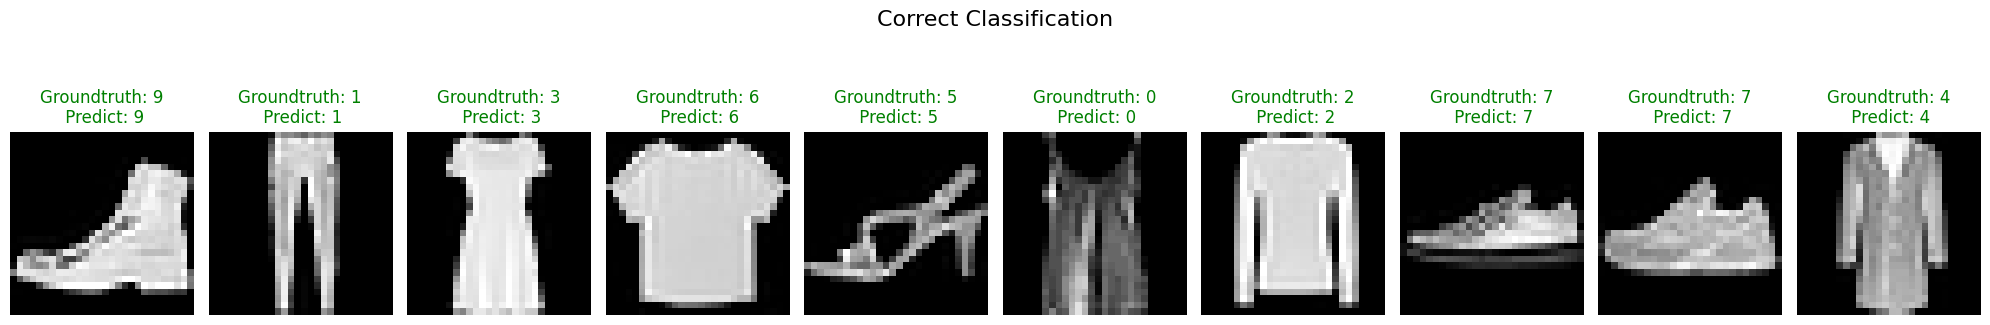

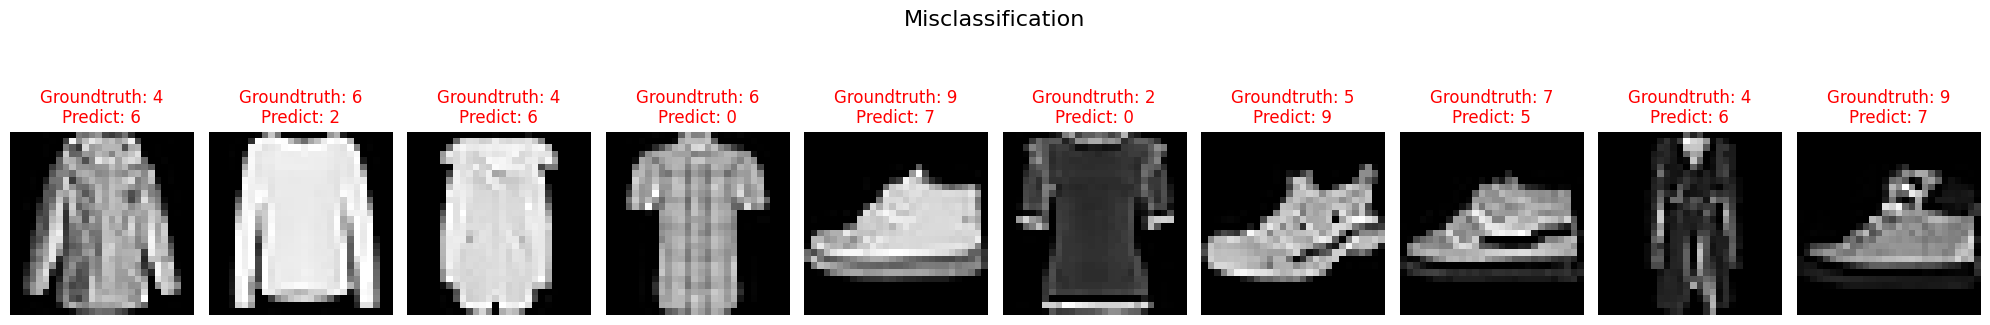

In [ ]:
visualize_predictions(
    model=model,
    X=X_test,
    Y_valid=Y_test,
    num_samples=10,
    image_shape=(28, 28)
)